# `nucleus_blobs`, step by step, on one small ROI

**Purpose.** `baselines.nucleus_blobs` is the comparator every experiment in this repo is
measured against -- "does one human click beat *any dark blob*". It is used everywhere and
shown nowhere: it is a single function call that returns a ranked table, and the six image
operations between the RGB pixels and that table are invisible. This notebook opens it up.

One deliberately small window is picked, and every intermediate is displayed:

| step | operation | `baselines.py` |
|---|---|---|
| 1 | tissue vs. slide glass, fixed brightness cut | `tissue_mask` |
| 2 | RGB -> hematoxylin by colour deconvolution | `channels.to_hematoxylin` |
| 3 | per-512-px-tile Otsu, bilinearly upsampled | `_tiled_otsu_threshold` |
| 4 | threshold to a binary foreground | `nucleus_blobs` body |
| 5 | 8-connected components | `nucleus_blobs` body |
| 6 | area gate, `80 <= area <= 4000` | `nucleus_blobs` body |
| 7 | rank by mean hematoxylin, darkest first | `nucleus_blobs` body |

Step 8 then calls `bl.nucleus_blobs(crop)` and checks it against the walkthrough, so this
is demonstrably the real function and not a parallel re-implementation that has drifted.

**This is a walkthrough, not an experiment.** It writes no CSV to `results/` and produces
no finding. Two things about running on a crop rather than a full 2 mm^2 ROI are worth
knowing before reading any number here as a full-ROI number:

* `to_hematoxylin` rescales by the **0.5/99.5 percentiles of whatever it is handed**, so
  the crop's hematoxylin channel is normalised against the crop's own dynamic range, not
  the ROI's. Absolute `score` values here are therefore not comparable with a full-ROI run.
* The tile grid is *not* affected. The crop origin (2560, 2560) and its size (1024) are
  both multiples of the 512 px tile, so the tile boundaries fall exactly where they fall in
  the full ROI. Only four tiles are involved instead of ~90.

Runtime is a couple of seconds of compute plus figure rendering -- see the last cell.

In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from matplotlib.patches import Circle, Rectangle
from skimage.color import label2rgb
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.segmentation import find_boundaries

from midog_utils import dataset as ds, baselines as bl, evaluate as ev

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 90
print('imports ok')

imports ok


## The ROI

`301.tiff` (canine cutaneous mast cell tumour, Aperio CS2, 0.2533 um/px -- the densest
downloaded ROI at 218 mitotic figures), a 1024 x 1024 window at (x=2560, y=2560).

**Why this window.** It is the 1024 px window in that ROI maximising the number of mitotic
annotations whose centres sit at least 80 px inside it, which is 12; the crop as loaded
contains 13 mitotic and 4 pathologist-marked look-alike annotations, the thirteenth sitting
close enough to the edge that its 50 px box is clipped. A window with one or zero annotations
would show the same seven steps but would make the final panel impossible to judge.

**Why a crop at all.** A full ROI is 6447 x 4835. Rendered small enough to fit on screen it
is roughly a 4x downsample, at which a nucleus is ~4 px across and the binary mask is a grey
haze -- the intermediate images, which are the entire point of this notebook, become
unreadable. 1024 px is small enough to display at ~1:1 and large enough to contain four
whole Otsu tiles.

The load uses `tifffile.memmap` rather than `ds.load_roi`: 001-406 are flat uncompressed
TIFFs, so the window can be read without decoding the other 148 MB. (`ds.load_roi` is the
right call for a whole ROI, and the only one that works for the 505/506 LZW pyramids.)

In [2]:
ROI_FILE = '301.tiff'
X0, Y0, SIZE = 2560, 2560, 1024      # origin and size are both multiples of the 512 px tile
path = f'images/{ROI_FILE}'

t0 = time.time()
mm = tifffile.memmap(path)                                  # no full-file decode
crop = np.ascontiguousarray(mm[Y0:Y0 + SIZE, X0:X0 + SIZE, :3])   # drop the uniform alpha
del mm
load_s = time.time() - t0

mpp = ds.roi_mpp(path)                       # microns per pixel, honouring ResolutionUnit
radius = ev.radius_px(mpp)                   # the evaluation match radius, in crop pixels
crop_mm2 = SIZE * SIZE * mpp * mpp / 1e6

_images, ann = ds.load_annotations()
gt_full = ds.image_annotations(ann, ROI_FILE)
in_crop = ((gt_full.cx >= X0) & (gt_full.cx < X0 + SIZE) &
           (gt_full.cy >= Y0) & (gt_full.cy < Y0 + SIZE))
gt = gt_full[in_crop].copy().reset_index(drop=True)
gt['cx'] -= X0                               # full-ROI -> crop coordinates. Everything
gt['cy'] -= Y0                               # downstream lives in crop coordinates.

print(f'{ROI_FILE} full ROI      : {gt_full.shape[0]} annotations over '
      f'{_images.loc[_images.file_name == ROI_FILE, "width"].iloc[0]} x '
      f'{_images.loc[_images.file_name == ROI_FILE, "height"].iloc[0]} px')
print(f'crop                 : {crop.shape}, {crop.dtype}, read in {load_s:.2f}s')
print(f'scale                : {mpp:.4f} um/px -> {crop_mm2:.3f} mm^2 '
      f'(a full MIDOG++ ROI is ~2 mm^2)')
print(f'match radius         : {radius:.1f} px  (7.5 um, the MIDOG++ evaluation radius)')
print(f'ground truth in crop : {int((gt.category_id == ds.MITOTIC).sum())} mitotic, '
      f'{int((gt.category_id == ds.LOOKALIKE).sum())} look-alike')

301.tiff full ROI      : 327 annotations over 6447 x 4835 px
crop                 : (1024, 1024, 3), uint8, read in 0.04s
scale                : 0.2533 um/px -> 0.067 mm^2 (a full MIDOG++ ROI is ~2 mm^2)
match radius         : 29.6 px  (7.5 um, the MIDOG++ evaluation radius)
ground truth in crop : 13 mitotic, 4 look-alike


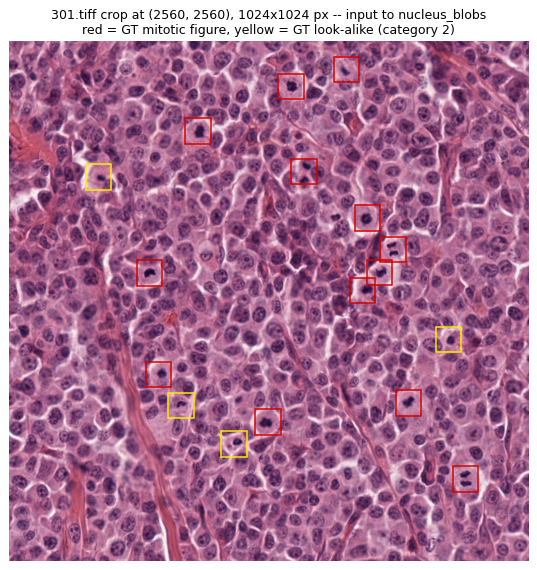

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(crop)
for _, a in gt.iterrows():
    color = '#d50000' if a.category_id == ds.MITOTIC else '#ffea00'
    ax.add_patch(Rectangle((a.cx - ds.BOX_SIZE / 2, a.cy - ds.BOX_SIZE / 2),
                           ds.BOX_SIZE, ds.BOX_SIZE,
                           fill=False, edgecolor=color, linewidth=1.2))
ax.set_title(f'{ROI_FILE} crop at ({X0}, {Y0}), {SIZE}x{SIZE} px -- input to nucleus_blobs\n'
             'red = GT mitotic figure, yellow = GT look-alike (category 2)', fontsize=10)
ax.axis('off')
plt.show()

## Step 1 -- `tissue_mask`: tissue vs. slide glass

`gray < 220` on the grayscale image, then a 9 px elliptical **closing** to fill small bright
holes inside tissue. Deliberately not Otsu, and deliberately no opening -- `tissue_mask`'s
docstring explains both (global Otsu splits tissue into dark and pale halves and pushed 31
of 301.tiff's mitotic figures outside "tissue"; a 9 px opening erases exactly the isolated
dark objects a nucleus detector is looking for).

**Expect this step to look like nothing happened.** This crop is near-solid tumour, so the
mask is a near-blank white square. That is the correct output, not a broken one: `tissue_mask`
earns its keep on ROIs with real glass in frame, and here it only matters as the domain the
next step's Otsu statistics are computed over. The count of excluded pixels below is the
honest measure of how much it does here.

tissue_mask: 0.00s
tissue fraction 0.9994  (620 of 1048576 px excluded as glass)


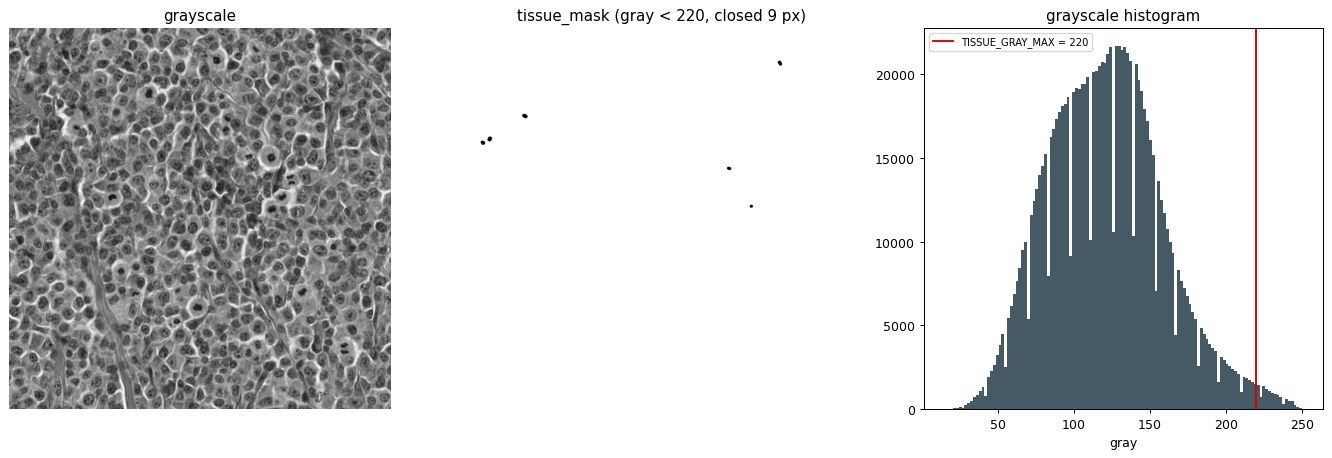

In [4]:
t0 = time.time()
mask = bl.tissue_mask(crop)
print(f'tissue_mask: {time.time() - t0:.2f}s')
print(f'tissue fraction {mask.mean():.4f}  '
      f'({int((~mask).sum())} of {mask.size} px excluded as glass)')

gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)      # exactly what tissue_mask thresholds
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255); axes[0].set_title('grayscale')
axes[1].imshow(mask, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'tissue_mask (gray < {bl.TISSUE_GRAY_MAX}, closed 9 px)')
axes[2].hist(gray.ravel(), bins=128, color='#455a64')
axes[2].axvline(bl.TISSUE_GRAY_MAX, color='#d50000', lw=1.5,
                label=f'TISSUE_GRAY_MAX = {bl.TISSUE_GRAY_MAX}')
axes[2].set_title('grayscale histogram'); axes[2].set_xlabel('gray'); axes[2].legend(fontsize=8)
for ax in axes[:2]:
    ax.axis('off')
fig.tight_layout(); plt.show()

## Step 2 -- `to_hematoxylin`: the channel the detector actually reads

`skimage.color.rgb2hed` colour deconvolution, hematoxylin channel only, rescaled to 0-255
between its 0.5 and 99.5 percentiles. Chromatin-selective and largely blind to eosin, so it
separates nucleus from cytoplasm in a way grayscale does not.

Note the polarity: **higher value = more chromatin**. Every threshold downstream is therefore
a `>`, not a `<`. This is the repo-wide convention (`channels.py`'s docstring) and is the
opposite of the reference particle-tracking code this pipeline was re-implemented from.

The percentile rescale is also the one place the crop is not equivalent to the full ROI:
the 0.5/99.5 cut points come from these 1.05 M pixels, not from the ROI's 31 M.

to_hematoxylin: 0.12s -> float32, range [0, 255], mean 68.4


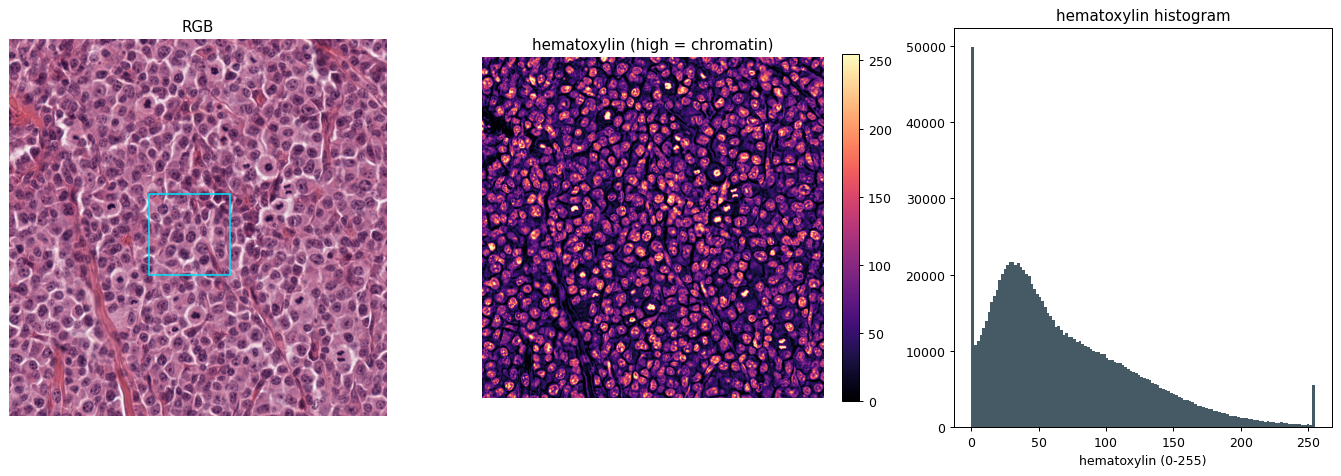

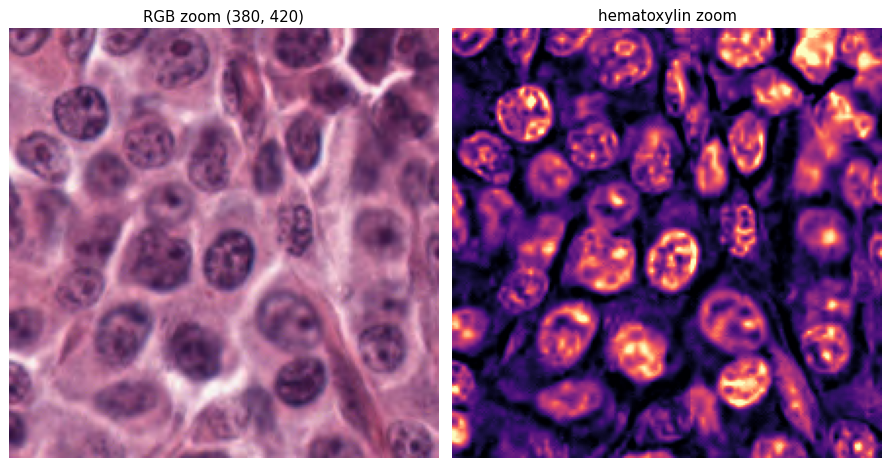

In [5]:
t0 = time.time()
h_chan = bl.to_hematoxylin(crop)
print(f'to_hematoxylin: {time.time() - t0:.2f}s -> {h_chan.dtype}, '
      f'range [{h_chan.min():.0f}, {h_chan.max():.0f}], mean {h_chan.mean():.1f}')

ZX, ZY, ZS = 380, 420, 220                    # a zoom window, reused for every later step
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
axes[0].imshow(crop); axes[0].set_title('RGB')
axes[0].add_patch(Rectangle((ZX, ZY), ZS, ZS, fill=False, edgecolor='#00e5ff', lw=1.2))
im = axes[1].imshow(h_chan, cmap='magma'); axes[1].set_title('hematoxylin (high = chromatin)')
fig.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].hist(h_chan.ravel(), bins=128, color='#455a64')
axes[2].set_title('hematoxylin histogram')
axes[2].set_xlabel('hematoxylin (0-255)')
for ax in axes[:2]:
    ax.axis('off')
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5.2))
axes[0].imshow(crop[ZY:ZY + ZS, ZX:ZX + ZS]); axes[0].set_title(f'RGB zoom ({ZX}, {ZY})')
axes[1].imshow(h_chan[ZY:ZY + ZS, ZX:ZX + ZS], cmap='magma')
axes[1].set_title('hematoxylin zoom')
for ax in axes:
    ax.axis('off')
fig.tight_layout(); plt.show()

## Step 3 -- `_tiled_otsu_threshold`: one Otsu per 512 px tile

A single global Otsu over a whole H&E ROI separates *dark tissue from pale tissue*, not
nucleus from cytoplasm, and returns one enormous connected component (`baselines.py`'s module
docstring). So Otsu is run per 512 px tile, over tissue pixels only, and the resulting coarse
grid is bilinearly upsampled to a full-resolution threshold map. A tile with fewer than 1000
tissue pixels, or no contrast, is left `nan` and filled with the median of the others.

The 1024 px crop is exactly a **2 x 2** grid, computed by hand below and then checked against
`bl._tiled_otsu_threshold`.

**Expect the threshold map to look flat.** The four tile thresholds span only a few grey
levels on this crop, so the upsampled map is very nearly a constant. The point of the tiling
is stain and focus drift across a 2 mm^2 ROI; a 1024 px window is smaller than the scale that
variation happens on. Printing the grid values is the only way to see the step at all, hence
the table.

per-tile Otsu threshold (rows = tile y, cols = tile x):
              x 0-512  x 512-1024
y 0-512     85.169998   87.160004
y 512-1024  84.169998   84.169998

global Otsu over the whole crop, for contrast: 85.17
_tiled_otsu_threshold: 0.02s -> map range [84.17, 87.16]


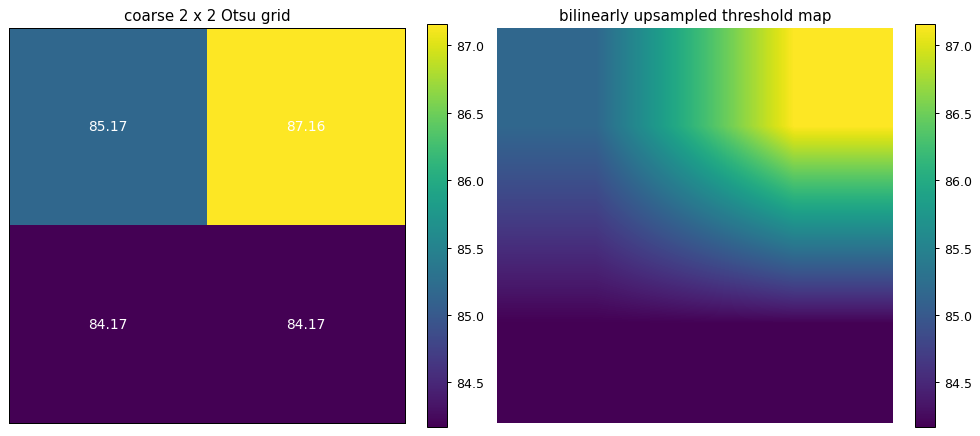

In [6]:
TILE = 512
ny, nx = int(np.ceil(SIZE / TILE)), int(np.ceil(SIZE / TILE))
grid = np.full((ny, nx), np.nan, dtype=np.float32)
for j in range(ny):
    for i in range(nx):
        sub = h_chan[j * TILE:(j + 1) * TILE, i * TILE:(i + 1) * TILE]
        sub_mask = mask[j * TILE:(j + 1) * TILE, i * TILE:(i + 1) * TILE]
        vals = sub[sub_mask]
        if vals.size < 1000 or vals.max() <= vals.min():
            continue                                    # too little tissue / no contrast
        grid[j, i] = threshold_otsu(vals)

print('per-tile Otsu threshold (rows = tile y, cols = tile x):')
print(pd.DataFrame(np.round(grid, 2),
                   index=[f'y {j * TILE}-{(j + 1) * TILE}' for j in range(ny)],
                   columns=[f'x {i * TILE}-{(i + 1) * TILE}' for i in range(nx)]))
print(f'\nglobal Otsu over the whole crop, for contrast: '
      f'{threshold_otsu(h_chan[mask]):.2f}')

t0 = time.time()
thr = bl._tiled_otsu_threshold(h_chan, mask, TILE)
print(f'_tiled_otsu_threshold: {time.time() - t0:.2f}s -> map range '
      f'[{thr.min():.2f}, {thr.max():.2f}]')
assert thr.shape == h_chan.shape
assert np.nanmin(grid) - 1e-3 <= thr.min() and thr.max() <= np.nanmax(grid) + 1e-3, \
    'the upsampled map should interpolate between the tile thresholds, never past them'

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
im = axes[0].imshow(grid, cmap='viridis')
for j in range(ny):
    for i in range(nx):
        axes[0].text(i, j, f'{grid[j, i]:.2f}', ha='center', va='center', color='w', fontsize=11)
axes[0].set_title(f'coarse {ny} x {nx} Otsu grid'); axes[0].set_xticks([]); axes[0].set_yticks([])
fig.colorbar(im, ax=axes[0], fraction=0.046)
im = axes[1].imshow(thr, cmap='viridis')
axes[1].set_title('bilinearly upsampled threshold map'); axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046)
fig.tight_layout(); plt.show()

## Step 4 -- threshold: `(h_chan > thr) & mask`

The pixelwise comparison against the upsampled map, restricted to tissue. This is the
foreground the rest of the method is built on.

The zoom is the informative panel here: at full-crop scale a 30% foreground fraction is a
grey texture, but zoomed in it is visibly nuclei, and the mitotic figures marked in red are
visibly solid blobs in it.

foreground fraction 0.3185 (333,956 of 1,048,576 px)


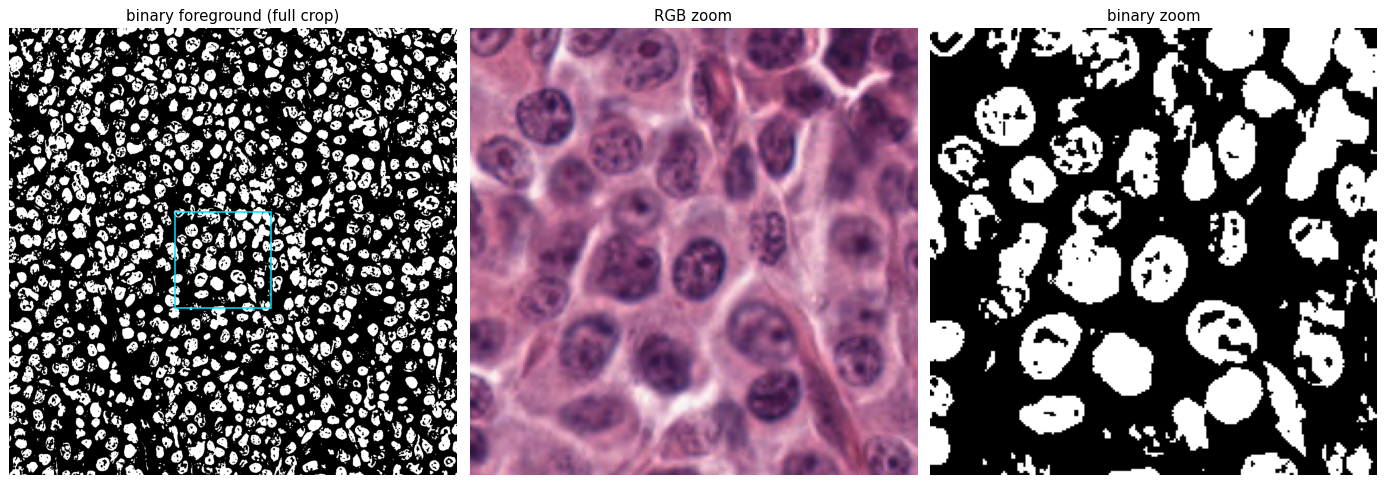

In [7]:
binary = (h_chan > thr) & mask
print(f'foreground fraction {binary.mean():.4f} '
      f'({int(binary.sum()):,} of {binary.size:,} px)')

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4))
axes[0].imshow(binary, cmap='gray'); axes[0].set_title('binary foreground (full crop)')
axes[0].add_patch(Rectangle((ZX, ZY), ZS, ZS, fill=False, edgecolor='#00e5ff', lw=1.2))
axes[1].imshow(crop[ZY:ZY + ZS, ZX:ZX + ZS]); axes[1].set_title('RGB zoom')
axes[2].imshow(binary[ZY:ZY + ZS, ZX:ZX + ZS], cmap='gray'); axes[2].set_title('binary zoom')
for a in gt.itertuples():
    if ZX <= a.cx < ZX + ZS and ZY <= a.cy < ZY + ZS:
        color = '#d50000' if a.category_id == ds.MITOTIC else '#ffea00'
        for ax in axes[1:]:
            ax.add_patch(Circle((a.cx - ZX, a.cy - ZY), 25, fill=False, edgecolor=color, lw=1.4))
for ax in axes:
    ax.axis('off')
fig.tight_layout(); plt.show()

## Step 5 -- `label(binary, connectivity=2)`: connected components

8-connectivity (`connectivity=2` in scikit-image's 2-D convention), so pixels touching only
at a corner join the same object. Every component is a candidate at this point -- including
every one-pixel speck of stain noise, which is what step 6 exists to remove.

label: 0.01s -> 1,979 raw connected components


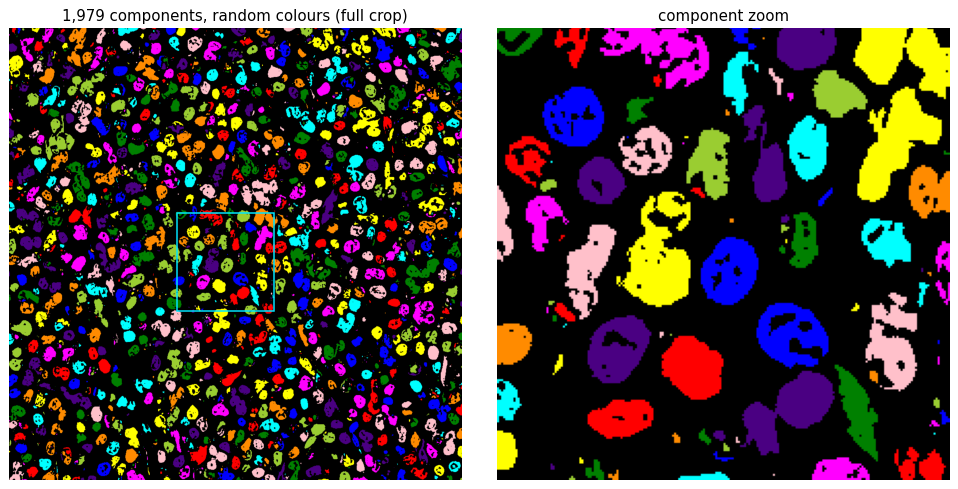

In [8]:
t0 = time.time()
lab = label(binary, connectivity=2)
n_raw = int(lab.max())
print(f'label: {time.time() - t0:.2f}s -> {n_raw:,} raw connected components')

overlay_zoom = label2rgb(lab[ZY:ZY + ZS, ZX:ZX + ZS], bg_label=0, bg_color=(0, 0, 0))
fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
axes[0].imshow(label2rgb(lab, bg_label=0, bg_color=(0, 0, 0)))
axes[0].set_title(f'{n_raw:,} components, random colours (full crop)')
axes[0].add_patch(Rectangle((ZX, ZY), ZS, ZS, fill=False, edgecolor='#00e5ff', lw=1.2))
axes[1].imshow(overlay_zoom); axes[1].set_title('component zoom')
for ax in axes:
    ax.axis('off')
fig.tight_layout(); plt.show()

## Step 6 -- the area gate, `80 <= area <= 4000` px

This is where the filtering actually happens: `nucleus_blobs` keeps only components whose
pixel area falls inside the gate, and it is the single step that removes the most candidates.

At this ROI's 0.2533 um/px, 80 px is a disc of about 2.6 um diameter and 4000 px about
18.1 um -- roughly "smaller than any nucleus" and "larger than any single nucleus". Both are
pixel counts, so both mean slightly different physical sizes on the four scanners in this
dataset.

The counts below are the honest accounting: raw -> rejected as too small -> rejected as too
large -> kept. Note in advance that on this crop the **upper** gate binds nothing; the
largest component is well under 4000 px. `max_area` exists to drop merged clumps of touching
nuclei, and this window does not contain one large enough. That is a property of this crop,
not evidence the gate is useless.

regionprops: 0.07s
raw components        : 1,979
  rejected, area < 80   : 1,259
  rejected, area > 4000 : 0
  kept                 : 720
kept area: min 80.0, median 390, max 2442.0


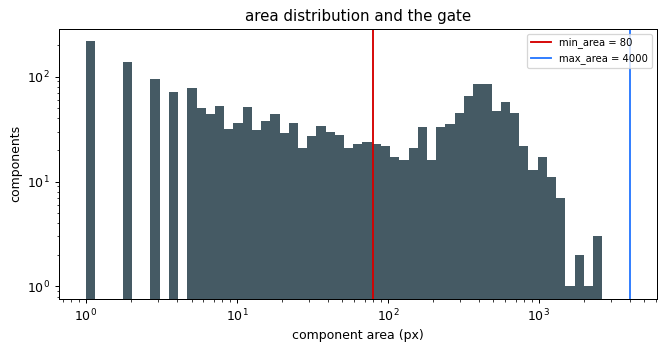

In [9]:
t0 = time.time()
props = regionprops(lab, intensity_image=h_chan)
areas = np.array([p.area for p in props])
print(f'regionprops: {time.time() - t0:.2f}s')

MIN_AREA, MAX_AREA = 80, 4000                             # nucleus_blobs' own defaults
too_small = areas < MIN_AREA
too_large = areas > MAX_AREA
kept_m = ~(too_small | too_large)
print(f'raw components        : {len(areas):,}')
print(f'  rejected, area < {MIN_AREA:<4} : {int(too_small.sum()):,}')
print(f'  rejected, area > {MAX_AREA:<4} : {int(too_large.sum()):,}')
print(f'  kept                 : {int(kept_m.sum()):,}')
print(f'kept area: min {areas[kept_m].min()}, median {np.median(areas[kept_m]):.0f}, '
      f'max {areas[kept_m].max()}')

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(areas, bins=np.logspace(0, np.log10(max(areas.max(), MAX_AREA)) , 60), color='#455a64')
ax.set_xscale('log'); ax.set_yscale('log')
ax.axvline(MIN_AREA, color='#d50000', lw=1.5, label=f'min_area = {MIN_AREA}')
ax.axvline(MAX_AREA, color='#2979ff', lw=1.5, label=f'max_area = {MAX_AREA}')
ax.set_xlabel('component area (px)'); ax.set_ylabel('components')
ax.set_title('area distribution and the gate'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

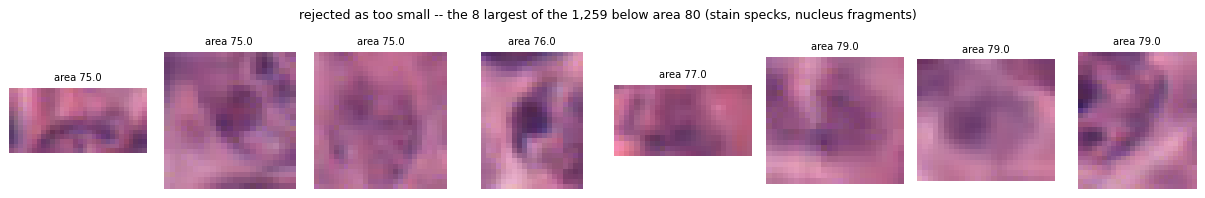

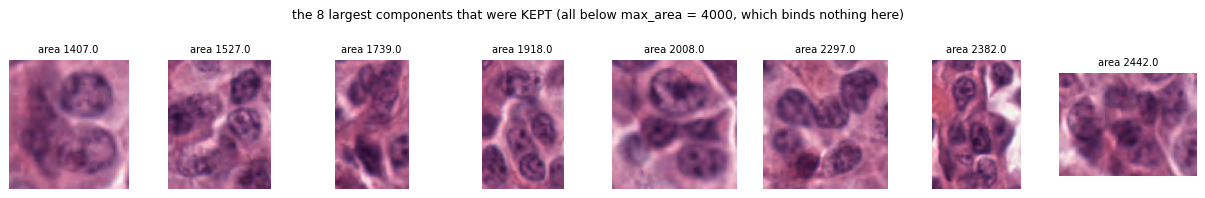

rejected as too large -- above area 4000: none on this crop


In [10]:
def patch_strip(prop_list, title, n=8, pad=6):
    # A row of RGB patches around the given regions, for eyeballing what a gate did.
    prop_list = prop_list[:n]
    if not prop_list:
        print(f'{title}: none on this crop')
        return
    fig, axes = plt.subplots(1, len(prop_list), figsize=(1.7 * len(prop_list), 2.2))
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, prop_list):
        r0, c0, r1, c1 = p.bbox
        r0, c0 = max(r0 - pad, 0), max(c0 - pad, 0)
        r1, c1 = min(r1 + pad, SIZE), min(c1 + pad, SIZE)
        ax.imshow(crop[r0:r1, c0:c1])
        ax.set_title(f'area {p.area}', fontsize=8)
        ax.axis('off')
    fig.suptitle(title, fontsize=10)
    fig.tight_layout(); plt.show()

order = np.argsort(areas)
patch_strip([props[i] for i in order if areas[i] < MIN_AREA][-8:],
            f'rejected as too small -- the 8 largest of the {int(too_small.sum()):,} below '
            f'area {MIN_AREA} (stain specks, nucleus fragments)')
patch_strip([props[i] for i in order if kept_m[i]][-8:],
            f'the 8 largest components that were KEPT (all below max_area = {MAX_AREA}, '
            'which binds nothing here)')
patch_strip([props[i] for i in order if too_large[i]][-8:],
            f'rejected as too large -- above area {MAX_AREA}')

## Step 7 -- rank by mean hematoxylin, darkest chromatin first

A connected-component set is *unordered*, and an unordered candidate list has no `recall@K`
and cannot be compared against a scored detector at a matched budget. `nucleus_blobs`
therefore ranks its survivors by `regionprops.mean_intensity` on the hematoxylin channel --
darkest mean chromatin first -- and that ordering is the whole reason the baseline is usable
as a baseline.

`max_detections` is `None` by default, i.e. no truncation. It used to default to 20000, which
silently bound on the two densest ROIs and kept only the *darkest*, hardest competitors,
biasing every rank statistic derived from it (`nucleus_blobs`' docstring). Nothing is
truncated here.

720 ranked candidates

 rank     cx     cy  score  area
    0 276.69 455.92 220.89   315
    1 556.32  88.88 215.73   376
    2 375.57 177.91 206.72   437
    3 505.82 751.29 206.30   417
    4 365.32   7.41 205.96   336
    5 757.27 417.64 204.20   166
    6 899.41 871.07 202.23   215
    7 703.00 349.96 200.82   420
...
 rank     cx     cy  score  area
  717 535.62 995.70  97.56   149
  718 159.44 567.12  96.43    81
  719 922.25 697.48  94.49    95


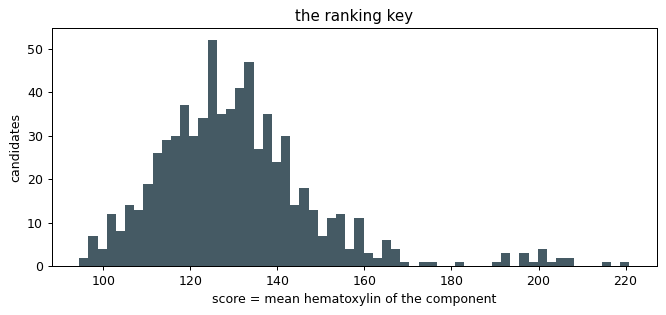

In [11]:
rows = [{'cx': p.centroid[1], 'cy': p.centroid[0],
         'score': float(p.mean_intensity), 'area': int(p.area)}
        for p in props if MIN_AREA <= p.area <= MAX_AREA]
manual = pd.DataFrame(rows, columns=['cx', 'cy', 'score', 'area'])
manual = manual.sort_values('score', ascending=False).reset_index(drop=True)
manual.insert(0, 'rank', np.arange(len(manual)))
print(f'{len(manual)} ranked candidates\n')
print(manual.head(8).round(2).to_string(index=False))
print('...')
print(manual.tail(3).round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(manual.score, bins=60, color='#455a64')
ax.set_xlabel('score = mean hematoxylin of the component')
ax.set_ylabel('candidates'); ax.set_title('the ranking key')
fig.tight_layout(); plt.show()

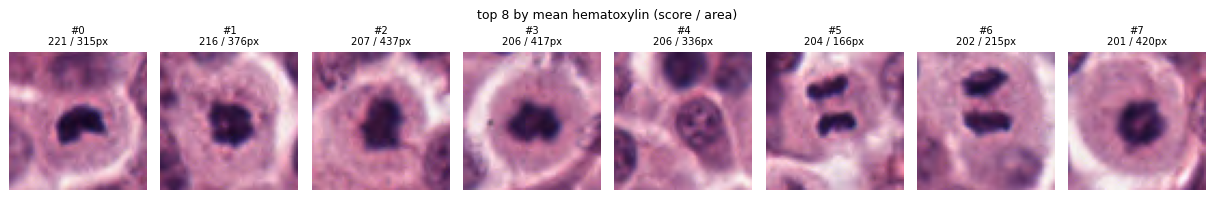

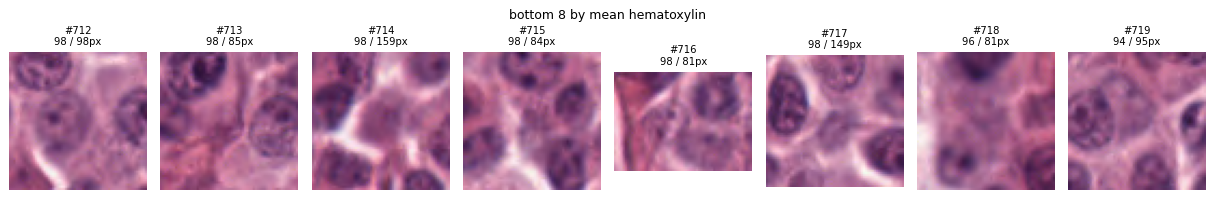

In [12]:
def rank_strip(df, idx, title, half=32):
    fig, axes = plt.subplots(1, len(idx), figsize=(1.7 * len(idx), 2.3))
    for ax, i in zip(np.atleast_1d(axes), idx):
        r = df.iloc[i]
        y, x = int(r.cy), int(r.cx)
        y0, x0 = max(y - half, 0), max(x - half, 0)
        ax.imshow(crop[y0:y0 + 2 * half, x0:x0 + 2 * half])
        ax.set_title(f'#{int(r["rank"])}\n{r.score:.0f} / {int(r.area)}px', fontsize=8)
        ax.axis('off')
    fig.suptitle(title, fontsize=10)
    fig.tight_layout(); plt.show()

rank_strip(manual, range(8), 'top 8 by mean hematoxylin (score / area)')
rank_strip(manual, range(len(manual) - 8, len(manual)), 'bottom 8 by mean hematoxylin')

## Step 8 -- is the walkthrough actually `nucleus_blobs`?

Everything above was assembled by hand out of the same primitives. That is only worth
anything if it reproduces the real function, so call it and compare.

The comparison is on `len` plus the **sorted** `(cx, cy, score, area)` tuples, not on row
order: components with identical `mean_intensity` are ties, and `sort_values`' default is not
a stable-order guarantee across two independently built frames.

In [13]:
t0 = time.time()
blobs = bl.nucleus_blobs(crop)
print(f'bl.nucleus_blobs(crop): {time.time() - t0:.2f}s -> {len(blobs)} candidates')

a = manual[['cx', 'cy', 'score', 'area']].round(6).sort_values(['cx', 'cy']).to_numpy()
b = blobs[['cx', 'cy', 'score', 'area']].round(6).sort_values(['cx', 'cy']).to_numpy()
assert len(manual) == len(blobs), f'{len(manual)} vs {len(blobs)}'
assert np.allclose(a, b), 'walkthrough and nucleus_blobs disagree on the candidate set'
assert np.array_equal(manual['score'].to_numpy(), blobs['score'].to_numpy()), \
    'same set, different ranking'
print('OK -- the walkthrough reproduces bl.nucleus_blobs exactly (set and ranking)')

bl.nucleus_blobs(crop): 0.24s -> 720 candidates
OK -- the walkthrough reproduces bl.nucleus_blobs exactly (set and ranking)


## The candidates on the final image

Two panels, because one picture cannot carry both facts.

**Panel 1 -- what was segmented.** Every kept component's actual boundary, plus its centroid.
This is the honest picture of the candidate set: it shows the segmentation the method
produced, at the resolution it produced it.

**Panel 2 -- what the scorer sees, top 25 only.** Each detection drawn at the 29.6 px match
radius and coloured by what it landed on. Only the top 25 are drawn, and that restriction is
not cosmetic: 720 candidates x pi x 29.6^2 is about 1.9x the crop's own area, so the full set
drawn at match radius carpets the image into a solid mat and would make any candidate look
like a hit. (This is the same failure mode `blob_coverage_check.py` was written to measure on
the watershed arm -- `ev.coverage_fraction` for the full set is printed below so the size of
the effect is visible rather than asserted.)

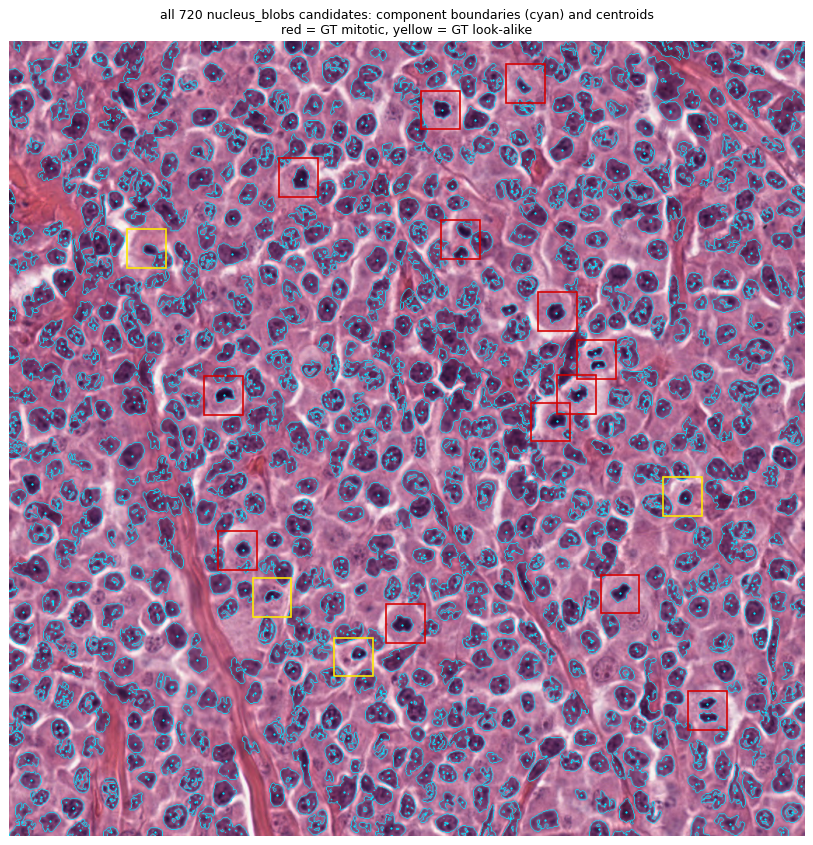

In [14]:
kept_props = [p for p in props if MIN_AREA <= p.area <= MAX_AREA]
kept_lab = np.zeros_like(lab)
for p in kept_props:
    kept_lab[lab == p.label] = p.label
bounds = find_boundaries(kept_lab, mode='outer')

vis = crop.astype(np.float32).copy()
vis[bounds] = [0, 229, 255]                                   # cyan component outlines

fig, ax = plt.subplots(figsize=(9.5, 9.5))
ax.imshow(vis.astype(np.uint8))
ax.plot(blobs.cx, blobs.cy, '.', color='#00e5ff', markersize=1.6)
for _, a_ in gt.iterrows():
    color = '#d50000' if a_.category_id == ds.MITOTIC else '#ffea00'
    ax.add_patch(Rectangle((a_.cx - ds.BOX_SIZE / 2, a_.cy - ds.BOX_SIZE / 2),
                           ds.BOX_SIZE, ds.BOX_SIZE,
                           fill=False, edgecolor=color, linewidth=1.3))
ax.set_title(f'all {len(blobs)} nucleus_blobs candidates: component boundaries (cyan) '
             'and centroids\nred = GT mitotic, yellow = GT look-alike', fontsize=10)
ax.axis('off')
fig.tight_layout(); plt.show()

crop coverage at the 29.6 px match radius: all 720 candidates 0.960, top 25 0.059
recall@K, K = 13 = mitotic GT in crop (so: over the top 13 only): 0.692

bucket counts over the top 25 drawn below (a longer list than K, so more mitotic figures are reached):
bucket
human_correct_label     13
non_human_findings       9
human_rejected_label     3


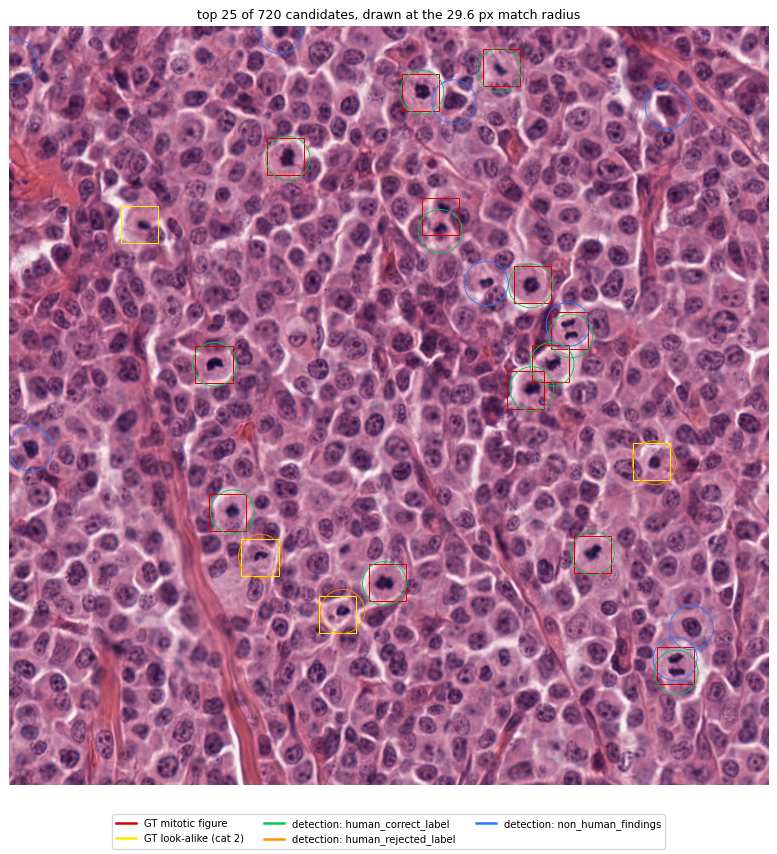

In [15]:
from midog_utils import viz

det_out, gt_out = ev.bucket_detections(blobs, gt, radius)
TOP_K = 25
cov_all = ev.coverage_fraction(blobs[['cx', 'cy']].to_numpy(), crop.shape[:2], radius, stride=8)
cov_top = ev.coverage_fraction(blobs[['cx', 'cy']].to_numpy()[:TOP_K], crop.shape[:2],
                               radius, stride=8)
n_mit = int((gt.category_id == ds.MITOTIC).sum())
print(f'crop coverage at the {radius:.1f} px match radius: '
      f'all {len(blobs)} candidates {cov_all:.3f}, top {TOP_K} {cov_top:.3f}')
print(f'recall@K, K = {n_mit} = mitotic GT in crop (so: over the top {n_mit} only): '
      f'{ev.recall_at_k(det_out["bucket"], n_mit, n_mit):.3f}')
print(f'\nbucket counts over the top {TOP_K} drawn below '
      f'(a longer list than K, so more mitotic figures are reached):')
print(det_out.head(TOP_K)['bucket'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(9.5, 9.5))
viz.overlay(crop, gt, det_out, ax=ax, downsample=1, top_n=TOP_K, radius=radius,
            title=f'top {TOP_K} of {len(blobs)} candidates, drawn at the {radius:.1f} px '
                  'match radius')
fig.legend(handles=viz.legend_handles()[:5], loc='lower center', ncol=3, fontsize=8)
fig.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()

## Runtime

In [16]:
print(f'notebook wall clock: {time.time() - NB_T0:.1f}s')

notebook wall clock: 10.6s
